<h1><center>Neighborhood Median Household Income Trends in Los Angeles County</center></h1>

<p><center>1. How have neighborhood-level median household income trends in Los Angeles County changed over time, and how are these trends discussed in existing urban policy coverage?</p></center>

In [49]:
# Packages necessary for evaluation and analysis. 
import pandas as pd 
import matplotlib.pyplot as plt 

In [50]:
# Inspecting the data and opening files. 
medianIncome = pd.read_csv('/Users/sergeantsharpe/Documents/GitHub/policy-data-exercises/data/All Years Median Household Income Calculations.csv')
medianIncome.head(5)
 

,geoid,geoid20,year,denom_total_hh,med_hh_inc_adj,med_hh_inc
0,1400000US06037101110,6037101110,2023,1679.0,84091.0,84091.0
1,1400000US06037101122,6037101122,2023,1452.0,99583.0,99583.0
2,1400000US06037101220,6037101220,2023,1380.0,69676.0,69676.0
3,1400000US06037101221,6037101221,2023,1569.0,53798.0,53798.0
4,1400000US06037101222,6037101222,2023,1036.0,45662.0,45662.0


In [51]:
medianIncome.dtypes #Inspecting the data types incase we need conversions.

geoid              object
geoid20             int64
year                int64
denom_total_hh    float64
med_hh_inc_adj    float64
med_hh_inc        float64
dtype: object

In [52]:
# To remove a column: df_new = df.drop(columns=['B'])
modifiedMedianIncome= medianIncome.drop(columns = ['geoid', 'geoid20'])
modifiedMedianIncome.head(13)

,year,denom_total_hh,med_hh_inc_adj,med_hh_inc
0,2023,1679.0,84091.0,84091.0
1,2023,1452.0,99583.0,99583.0
2,2023,1380.0,69676.0,69676.0
3,2023,1569.0,53798.0,53798.0
4,2023,1036.0,45662.0,45662.0
5,2023,1564.0,125675.0,125675.0
6,2023,1523.0,81154.0,81154.0
7,2023,821.0,72656.0,72656.0
8,2023,1418.0,107656.0,107656.0
9,2023,561.0,96167.0,96167.0


In [53]:
# Code did not end up working as intended by almost, can try again in a future attempt. 
# # Taking the sum of columns for year + med_hh_inc_adj values 
# data = modifiedMedianIncome['med_hh_inc_adj']
# years = modifiedMedianIncome['year']

# totalModifiedMedianIncome = modifiedMedianIncome['med_hh_inc_adj'].sum()
# #Testing for output 
# print(totalModifiedMedianIncome.head(5))

In [54]:
# # df = pd.read_csv('your_data.csv', index_col='DateColumnName', parse_dates=True)
# # Ensure the index is explicitly a DatetimeIndex
# modifiedMedianIncome.index = pd.to_datetime(modifiedMedianIncome.index)

# # 2. Group by the year from the index and sum a specific column
# # Replace 'Sales' with the name of the column you want to sum
# yearly_sum = modifiedMedianIncome.groupby(modifiedMedianIncome.index.year)['med_hh_inc_adj'].sum()

# # Print the result
# print("Yearly Sum of Sales:")
# print(yearly_sum)

In [55]:
yearly_median = (
    modifiedMedianIncome
        .groupby('year')['med_hh_inc_adj']
        .median()
)


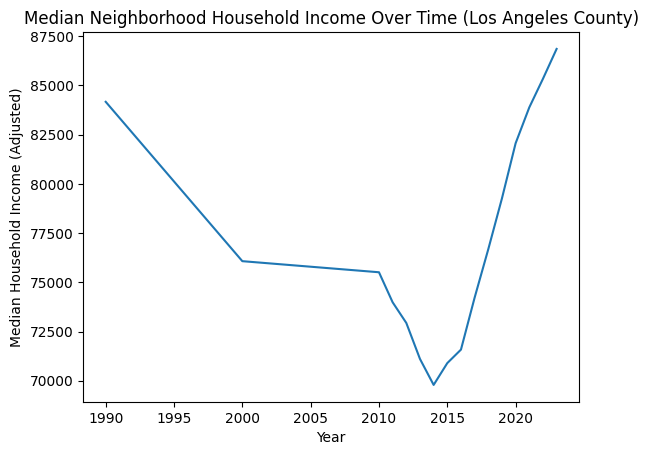

In [56]:
plt.figure()
plt.plot(yearly_median.index, yearly_median.values)
plt.xlabel("Year")
plt.ylabel("Median Household Income (Adjusted)")
plt.title("Median Neighborhood Household Income Over Time (Los Angeles County)")
plt.show()


<h1><center>Total Population</h1></center>


<h3>Information from the Data Exchange</h3>


<p><center>Measuring the total number of people in an area or neighborhood is useful by itself and as a complement to many other measures. Total population in a neighborhood shows that neighborhood’s population density, which can have implications for the health, housing and job availability, education quality, and local government tax revenue. Total population is also a vital tool for understanding how various indicators impact a group of people based on their population size, and the variable is used for many calculations throughout the NDSC data.

</center></p>

In [57]:
totalPop = pd.read_csv('/Users/sergeantsharpe/Documents/GitHub/policy-data-exercises/data/All Years Total Population Calculations.csv')
totalPop.head(5)

,geoid,geoid20,year,total_pop
0,1400000US06037101110,6037101110,2023,4152
1,1400000US06037101122,6037101122,2023,4198
2,1400000US06037101220,6037101220,2023,3434
3,1400000US06037101221,6037101221,2023,3931
4,1400000US06037101222,6037101222,2023,2572


In [58]:
modifiedTotalPop = totalPop.drop(columns = ['geoid', 'geoid20'])
totalPop.groupby('year', as_index=False)['total_pop']
modifiedTotalPop = totalPop['total_pop'].sum()

print("The population in total from 2008-2024,is: ")
print( modifiedTotalPop) 


The population in total from 2008-2024,is: 
157797819


In [60]:

x = totalPop['year']
y = totalPop['total_pop']
fig = plt.figure() 
fig.set_size_inches(12, 5)
plt.bar(x = totalPop['year'], y = totalPop['total_pop'])
plt.title("Total Population by Year 2008-2024")
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()

TypeError: bar() missing 1 required positional argument: 'height'

<Figure size 1200x500 with 0 Axes>

<Axes: title={'center': 'Total Population by Year (2008–2024)'}, xlabel='year'>

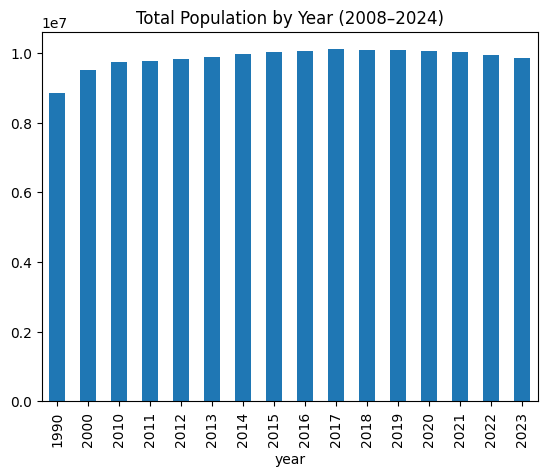

In [ ]:
# Preparing the plot 
annual_pop = (
    totalPop
        .drop(columns=['geoid', 'geoid20'])
        .groupby('year', as_index=False)['total_pop']
        .sum()
)

annual_pop.plot(
    x='year',
    y='total_pop',
    kind='bar',
    legend=False,
    title='Total Population by Year (2008–2024)'
)




The population in total from 2008–2024 is:
157797819


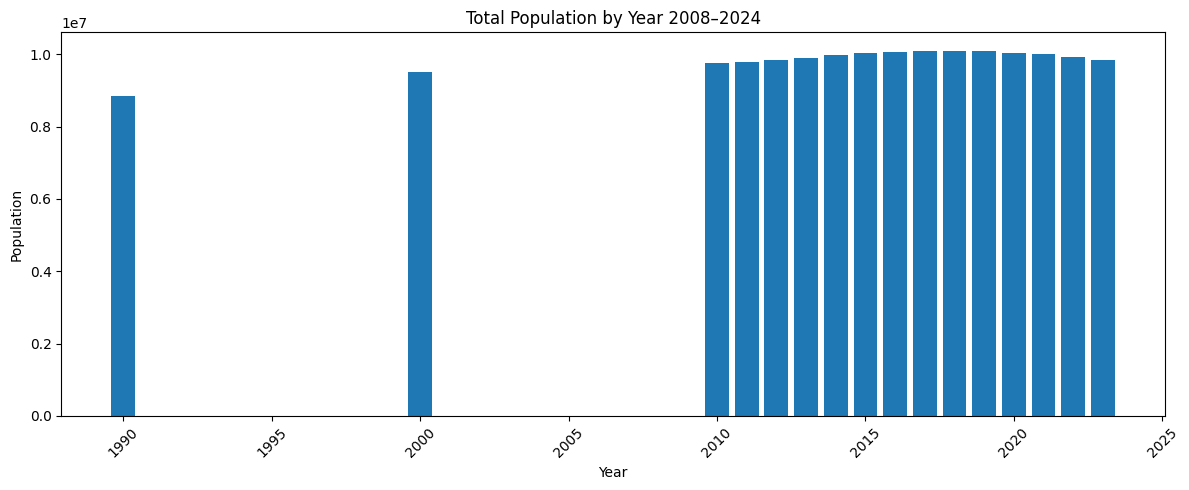

In [63]:
# 1) Aggregate to annual totals (THIS is what your bar plot needs)
annual_pop = (
    totalPop
      .groupby('year', as_index=False)['total_pop']
      .sum()
)

# 2) Total across 2008–2024 (for your message)
total_2008_2024 = annual_pop['total_pop'].sum()

print("The population in total from 2008–2024 is:")
print(total_2008_2024)

# 3) Bar plot using the aggregated data
plt.figure(figsize=(12, 5))
plt.bar(x=annual_pop['year'], height=annual_pop['total_pop'])
plt.title("Total Population by Year 2008–2024")
plt.xlabel("Year")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
